<a href="https://colab.research.google.com/github/beyonddbold-ux/ML-Models/blob/main/Predictive%20analytics%20sparkling%20sales%20data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Time Series Analysis of Sparkling Wine Sales

In [2]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.api import SimpleExpSmoothing, Holt, ExponentialSmoothing
from statsmodels.tsa.ar_model import AutoReg # Added AutoReg import
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

### 1. Library Imports and Setup

This section imports all necessary libraries for data manipulation, time series analysis, modeling, and plotting. It also sets up matplotlib for inline plotting and suppresses warnings for cleaner output.

In [3]:
df = pd.read_csv('/content/Sparkling.csv')
df.head()

,YearMonth,Sparkling
0,1980-01,1686
1,1980-02,1591
2,1980-03,2304
3,1980-04,1712
4,1980-05,1471


### 2. Data Loading and Initial Inspection

The `Sparkling.csv` dataset is loaded into a pandas DataFrame. The `head()` method is used to display the first few rows, giving a quick overview of the data structure, which includes `YearMonth` and `Sparkling` sales columns.

In [4]:
df['YearMonth'] = pd.to_datetime(df['YearMonth'], format='%Y-%m')
df.set_index('YearMonth', inplace=True)
df = df.asfreq('MS')

test_size = 12
train = df.iloc[:-test_size]
test = df.iloc[-test_size:]

### 3. Data Preprocessing and Train/Test Split

Here, the `YearMonth` column is converted to a datetime object and set as the DataFrame index. The data is then re-indexed to ensure a monthly frequency (`MS`). Finally, the dataset is split into training (all data except the last 12 months) and testing (the last 12 months) sets to evaluate forecast performance.

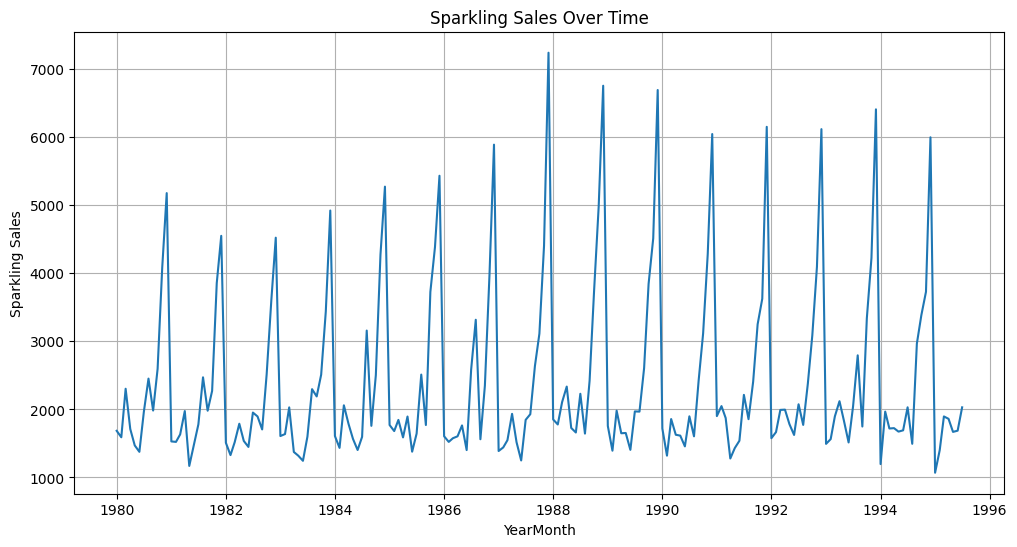

In [5]:
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Sparkling'])
plt.title('Sparkling Sales Over Time')
plt.xlabel('YearMonth')
plt.ylabel('Sparkling Sales')
plt.grid(True)
plt.show()

### 4. Overall Sales Visualization

This plot visualizes the `Sparkling` sales data over the entire period. It helps in understanding the overall trend, seasonality, and any major anomalies present in the time series.

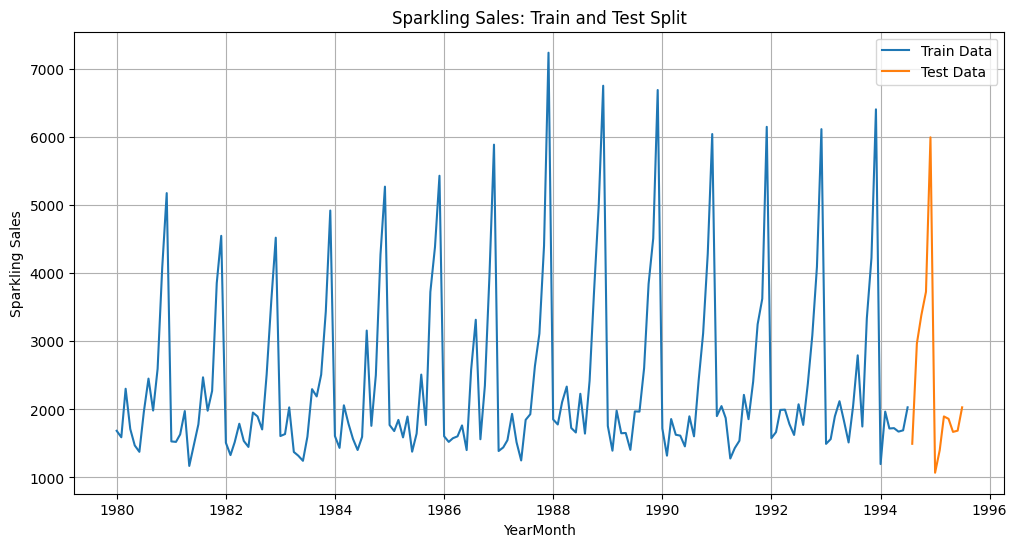

In [6]:
plt.figure(figsize=(12, 6))
plt.plot(train.index, train['Sparkling'], label='Train Data')
plt.plot(test.index, test['Sparkling'], label='Test Data')
plt.title('Sparkling Sales: Train and Test Split')
plt.xlabel('YearMonth')
plt.ylabel('Sparkling Sales')
plt.legend()
plt.grid(True)
plt.show()

### 5. Train and Test Split Visualization

This plot clearly distinguishes between the training and testing datasets. It shows which portion of the data was used for model training and which portion is reserved for evaluating the models' forecasting accuracy against unseen data.

### Seasonal Decomposition (Multiplicative Model)

### 6. Seasonal Decomposition (Multiplicative Model)

Seasonal decomposition breaks down the time series into its constituent components: trend, seasonality, and residuals. A multiplicative model is used, assuming that the components multiply to form the observed series. The plot shows these individual components, revealing clear seasonality and an underlying trend.

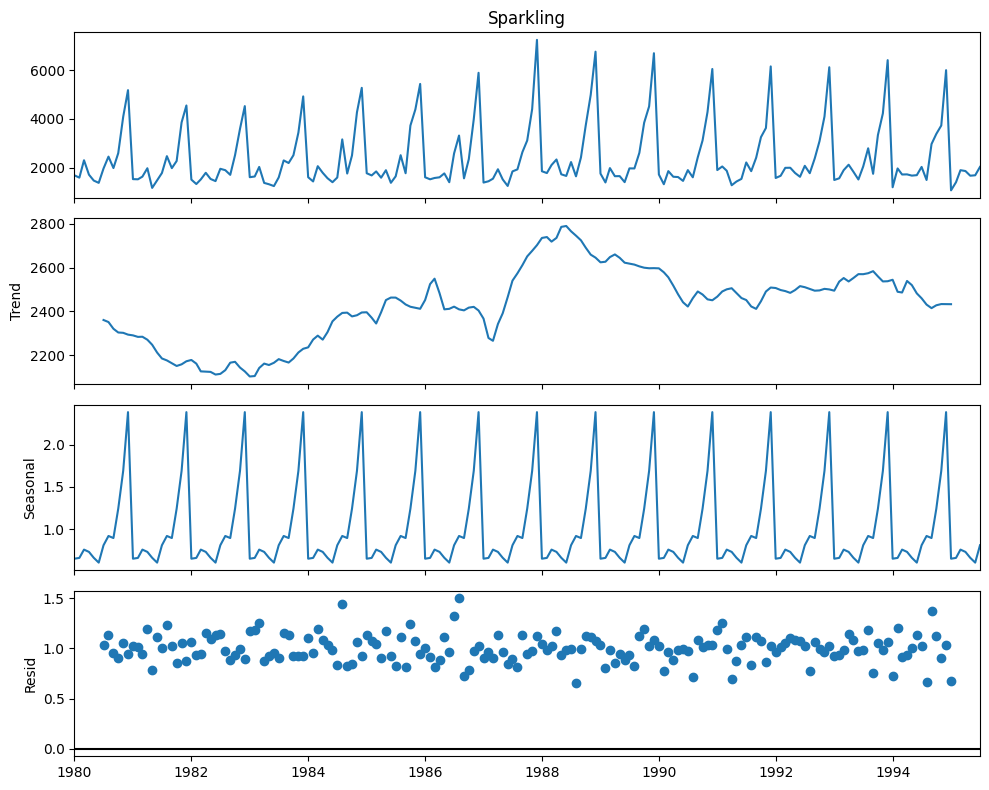

In [7]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Perform multiplicative seasonal decomposition
decomposition = seasonal_decompose(df['Sparkling'], model='multiplicative')

# Plot the decomposed components
fig = decomposition.plot()
fig.set_size_inches(10, 8)
plt.tight_layout()
plt.show()

Monthly Distribution of Sparkling Sales (Boxplot)

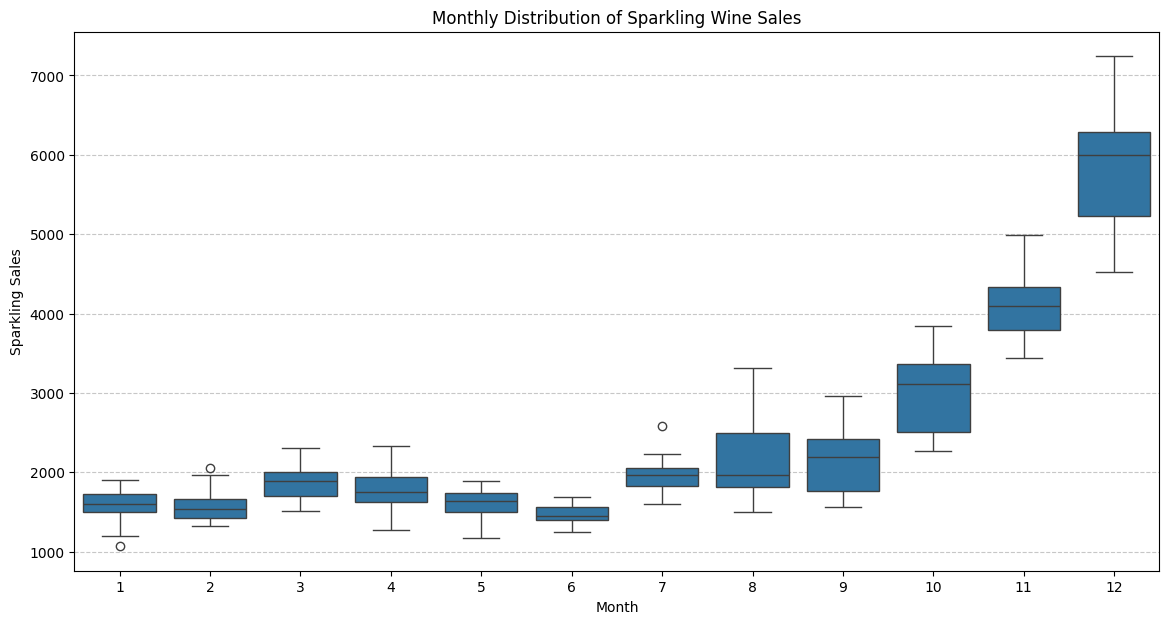

In [8]:
import seaborn as sns

# Extract month from the index
df['Month'] = df.index.month

# Create a boxplot
plt.figure(figsize=(14, 7))
sns.boxplot(x='Month', y='Sparkling', data=df)
plt.title('Monthly Distribution of Sparkling Wine Sales')
plt.xlabel('Month')
plt.ylabel('Sparkling Sales')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 7. Monthly Distribution of Sparkling Sales (Boxplot)

This boxplot illustrates the distribution of sparkling sales for each month of the year. It provides a clearer picture of the seasonal patterns, highlighting which months typically have higher or lower sales and the variability within each month.

In [9]:
from sklearn.metrics import mean_squared_error

mean_forecast = np.full(len(test), train['Sparkling'].mean())
rmse_mean = np.sqrt(mean_squared_error(test['Sparkling'], mean_forecast))
print("RMSE (Mean):", rmse_mean)

RMSE (Mean): 1332.7298359882745


### 8. Baseline Forecasting Models: Mean, Last Value, SES, and DES

This section implements and evaluates several simple baseline forecasting models:
- **Mean Forecast:** Predicts the average of the training data for all future periods.
- **Last Value Forecast:** Predicts the last observed value from the training data for all future periods.
- **Simple Exponential Smoothing (SES):** A basic exponential smoothing method suitable for data with no clear trend or seasonality.
- **Holt (Double Exponential Smoothing - DES):** An extension of SES that accounts for trend.

The Root Mean Squared Error (RMSE) is calculated for each to establish benchmarks for more complex models.

In [10]:
last_value_forecast = np.full(len(test), train['Sparkling'].iloc[-1])
rmse_last = np.sqrt(mean_squared_error(test['Sparkling'], last_value_forecast))
print("RMSE (Last value):", rmse_last)

RMSE (Last value): 1391.6554290963454


In [11]:
from statsmodels.tsa.api import SimpleExpSmoothing
ses_model = SimpleExpSmoothing(train['Sparkling'], initialization_method='estimated').fit()
ses_forecast = ses_model.forecast(len(test))
rmse_ses = np.sqrt(mean_squared_error(test['Sparkling'], ses_forecast))
print("RMSE (SES):", rmse_ses)

RMSE (SES): 1332.7298957882438


In [12]:
from statsmodels.tsa.api import Holt
des_model = Holt(train['Sparkling'], initialization_method='estimated').fit()
des_forecast = des_model.forecast(len(test))
rmse_des = np.sqrt(mean_squared_error(test['Sparkling'], des_forecast))
print("RMSE (DES):", rmse_des)

RMSE (DES): 1327.695464080199


RMSE (Holt-Winters): 396.74971890852305


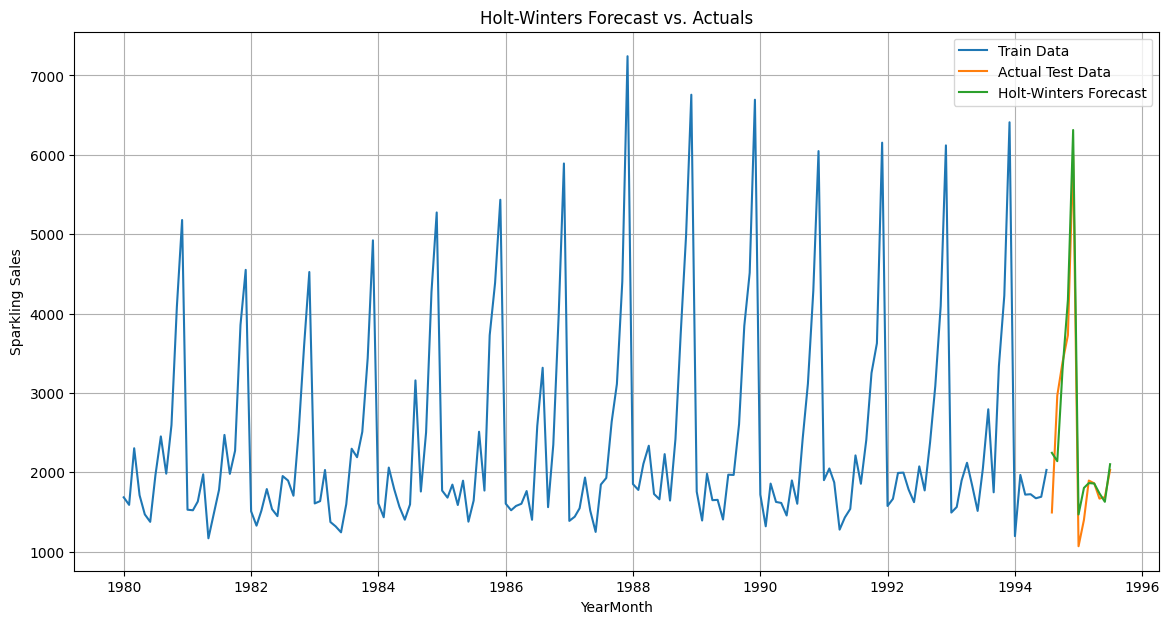

In [13]:
from statsmodels.tsa.api import ExponentialSmoothing
# Holt-Winters (Triple Exponential Smoothing)
hw_model = ExponentialSmoothing(train['Sparkling'], trend='add', seasonal='add', seasonal_periods=12, initialization_method='estimated').fit()
hw_forecast = hw_model.forecast(len(test))
rmse_hw = np.sqrt(mean_squared_error(test['Sparkling'], hw_forecast))
print("RMSE (Holt-Winters):", rmse_hw)

plt.figure(figsize=(14, 7))
plt.plot(train.index, train['Sparkling'], label='Train Data')
plt.plot(test.index, test['Sparkling'], label='Actual Test Data')
plt.plot(hw_forecast.index, hw_forecast, label='Holt-Winters Forecast')
plt.title('Holt-Winters Forecast vs. Actuals')
plt.xlabel('YearMonth')
plt.ylabel('Sparkling Sales')
plt.legend()
plt.grid(True)
plt.show()

### 9. Holt-Winters (Triple Exponential Smoothing) Model

The Holt-Winters model extends exponential smoothing to handle trend and seasonality. This implementation uses additive trend and seasonal components with a seasonal period of 12 (for monthly data). The forecast is plotted against the actual test data to visually assess its performance, and its RMSE is calculated.

In [14]:
tes_model = ExponentialSmoothing(train['Sparkling'],
                                  trend='additive',
                                  seasonal='additive',
                                  seasonal_periods=12,
                                  initialization_method='estimated').fit()
tes_forecast = tes_model.forecast(len(test))
rmse_tes = np.sqrt(mean_squared_error(test['Sparkling'], tes_forecast))
print("RMSE (TES):", rmse_tes)

RMSE (TES): 396.74971890852305


### 10. Time Series Stationarity Analysis

Before applying ARIMA-family models, it's crucial to check for stationarity. Stationary time series have properties (mean, variance, autocorrelation) that do not change over time, making them easier to model. The following sections explore this aspect.

### Plotting Autocorrelation Function (ACF)

### 11. Plotting Autocorrelation Function (ACF)

The ACF plot shows the correlation of a time series with its own past values (lags). Significant spikes at certain lags indicate patterns like seasonality. For the original series, strong autocorrelations are visible, especially at seasonal lags, suggesting non-stationarity and seasonality.

<Figure size 1200x600 with 0 Axes>

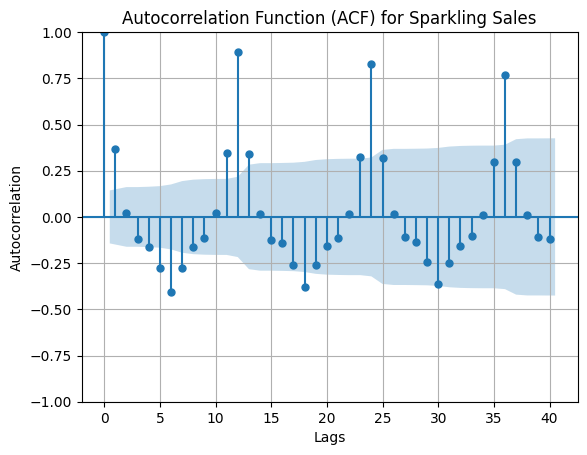

In [15]:
plt.figure(figsize=(12, 6))
plot_acf(df['Sparkling'], lags=40)
plt.title('Autocorrelation Function (ACF) for Sparkling Sales')
plt.xlabel('Lags')
plt.ylabel('Autocorrelation')
plt.grid(True)
plt.show()

### Plotting Partial Autocorrelation Function (PACF)

<Figure size 1200x600 with 0 Axes>

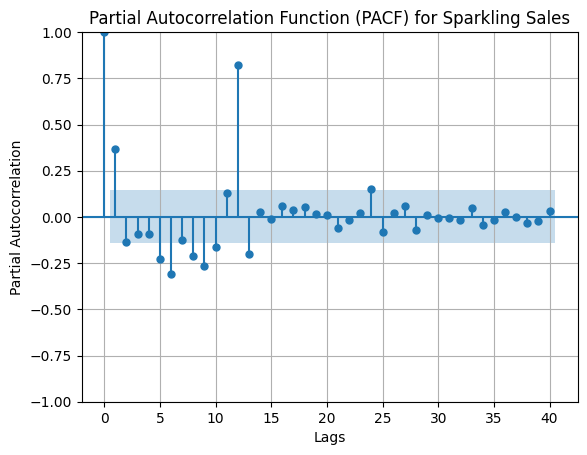

In [16]:
plt.figure(figsize=(12, 6))
plot_pacf(df['Sparkling'], lags=40)
plt.title('Partial Autocorrelation Function (PACF) for Sparkling Sales')
plt.xlabel('Lags')
plt.ylabel('Partial Autocorrelation')
plt.grid(True)
plt.show()

### 12. Plotting Partial Autocorrelation Function (PACF)

The PACF plot shows the direct correlation between a time series and its past values, removing the influence of intermediate lags. This plot helps in determining the order of the AutoRegressive (AR) component in ARIMA models.

### Augmented Dickey-Fuller (ADF) Test for Stationarity

### 13. Augmented Dickey-Fuller (ADF) Test for Stationarity

The ADF test is a statistical test to determine if a time series is stationary. A low p-value (typically <= 0.05) indicates stationarity. The initial ADF test result indicates that the original `Sparkling` sales series is non-stationary, as its p-value is greater than 0.05.

In [17]:
# Perform ADF test
adf_result = adfuller(df['Sparkling'])

print(f'ADF Statistic: {adf_result[0]}')
print(f'p-value: {adf_result[1]}')
print('Critical Values:')
for key, value in adf_result[4].items():
    print(f'   {key}: {value}')

if adf_result[1] <= 0.05:
    print("Conclusion: The time series is stationary (reject H0)")
else:
    print("Conclusion: The time series is non-stationary (fail to reject H0)")

ADF Statistic: -1.3604974548123345
p-value: 0.6010608871634866
Critical Values:
   1%: -3.4682803641749267
   5%: -2.8782017240816327
   10%: -2.5756525795918366
Conclusion: The time series is non-stationary (fail to reject H0)


### Performing First-Order Differencing

### 14. Performing First-Order Differencing

To achieve stationarity, first-order differencing is applied to the `Sparkling` sales series. This involves subtracting the previous observation from the current observation. The new `Sparkling_diff` column represents the changes in sales from month to month.

In [18]:
# Perform first-order differencing
df['Sparkling_diff'] = df['Sparkling'].diff().dropna()

print("DataFrame after first-order differencing:")
display(df.head())

DataFrame after first-order differencing:


,Sparkling,Month,Sparkling_diff
YearMonth,,,
1980-01-01,1686,1,NaN
1980-02-01,1591,2,-95.0
1980-03-01,2304,3,713.0
1980-04-01,1712,4,-592.0
1980-05-01,1471,5,-241.0


### Re-running ADF Test on Differenced Series

In [19]:
# Perform ADF test on the differenced series
adf_result_diff = adfuller(df['Sparkling_diff'].dropna())

print(f'ADF Statistic (Differenced): {adf_result_diff[0]}')
print(f'p-value (Differenced): {adf_result_diff[1]}')
print('Critical Values (Differenced):')
for key, value in adf_result_diff[4].items():
    print(f'   {key}: {value}')

if adf_result_diff[1] <= 0.05:
    print("Conclusion: The differenced time series is stationary (reject H0)")
else:
    print("Conclusion: The differenced time series is non-stationary (fail to reject H0)")

ADF Statistic (Differenced): -45.05030093619526
p-value (Differenced): 0.0
Critical Values (Differenced):
   1%: -3.4682803641749267
   5%: -2.8782017240816327
   10%: -2.5756525795918366
Conclusion: The differenced time series is stationary (reject H0)


### 15. Re-running ADF Test on Differenced Series

The ADF test is performed again on the first-order differenced series. The significantly lower p-value (0.0) confirms that the differenced series is now stationary, making it suitable for ARMA modeling.

### Plotting Autocorrelation Function (ACF) for Differenced Series

<Figure size 1200x600 with 0 Axes>

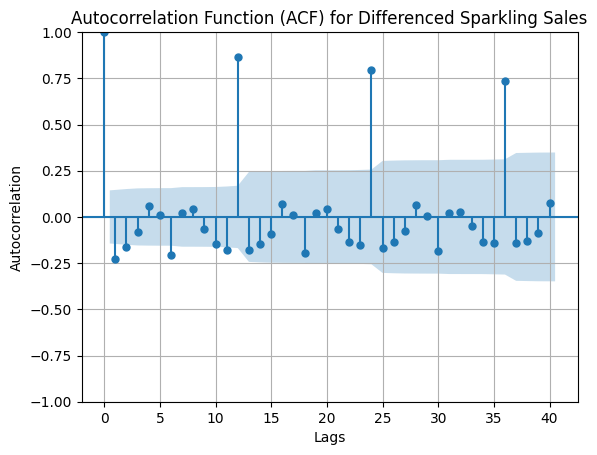

In [20]:
plt.figure(figsize=(12, 6))
plot_acf(df['Sparkling_diff'].dropna(), lags=40)
plt.title('Autocorrelation Function (ACF) for Differenced Sparkling Sales')
plt.xlabel('Lags')
plt.ylabel('Autocorrelation')
plt.grid(True)
plt.show()

### 16. Plotting Autocorrelation Function (ACF) for Differenced Series

The ACF plot of the differenced series shows a rapid decay in autocorrelations, confirming better stationarity. Residual spikes can still provide clues for the Moving Average (MA) component order.

### Plotting Partial Autocorrelation Function (PACF) for Differenced Series

<Figure size 1200x600 with 0 Axes>

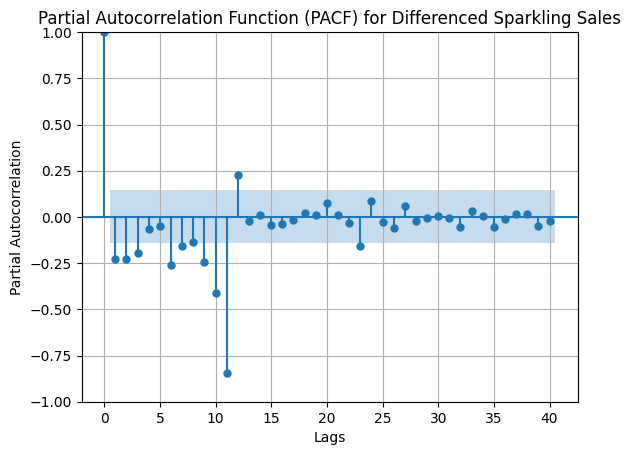

In [21]:
plt.figure(figsize=(12, 6))
plot_pacf(df['Sparkling_diff'].dropna(), lags=40)
plt.title('Partial Autocorrelation Function (PACF) for Differenced Sparkling Sales')
plt.xlabel('Lags')
plt.ylabel('Partial Autocorrelation')
plt.grid(True)
plt.show()

### 17. Plotting Partial Autocorrelation Function (PACF) for Differenced Series

The PACF plot of the differenced series helps in identifying the order of the AutoRegressive (AR) component for the ARMA model. Significant spikes indicate the direct correlation at those specific lags.

### Grid Search for Optimal ARMA(p,q) Parameters

Now that we have differenced the series to make it stationary, we can perform a grid search to find the optimal `p` (AR order) and `q` (MA order) for an ARMA model. We will use the Akaike Information Criterion (AIC) and Bayesian Information Criterion (BIC) to evaluate different models, aiming for the lowest values.

### 18. Grid Search for Optimal ARMA(p,q) Parameters

This section performs a grid search over various combinations of `p` (AR order) and `q` (MA order) for an ARMA model. The Akaike Information Criterion (AIC) and Bayesian Information Criterion (BIC) are used to evaluate model fit, with lower values indicating a better model. The differenced series is used here, so the integrated (I) order `d` is set to 0 in `ARIMA(p,0,q)`.

In [22]:
import itertools
from statsmodels.tsa.arima.model import ARIMA

# Define the p and q ranges to test
p_values = range(0, 3)
q_values = range(0, 3)

# Create a list to store the results
results = []

# Loop through all possible combinations of p and q
for p, q in itertools.product(p_values, q_values):
    try:
        # Fit ARMA model (d=0 since we are using the differenced series)
        model = ARIMA(df['Sparkling_diff'].dropna(), order=(p, 0, q))
        model_fit = model.fit()
        results.append({
            'p': p,
            'q': q,
            'AIC': model_fit.aic,
            'BIC': model_fit.bic
        })
    except:
        continue

# Convert results to a DataFrame and sort by AIC
grid_df = pd.DataFrame(results).sort_values(by='AIC').reset_index(drop=True)

display(grid_df.head())

,p,q,AIC,BIC
0,2,2,3174.998920,3194.353400
1,2,1,3177.371994,3193.500727
2,0,2,3177.522086,3190.425073
3,1,2,3178.452755,3194.581488
4,1,1,3178.590145,3191.493132


In [23]:
best_p, best_q = int(grid_df.iloc[0]['p']), int(grid_df.iloc[0]['q'])
print(f"Best ARMA order by AIC: p = {best_p}, q = {best_q}")
print(f"AIC = {grid_df.iloc[0]['AIC']:.2f} | BIC = {grid_df.iloc[0]['BIC']:.2f}")

Best ARMA order by AIC: p = 2, q = 2
AIC = 3175.00 | BIC = 3194.35


### 19. Best ARMA Order Selection

Based on the grid search, the ARMA model with the lowest AIC is identified as the optimal combination of `p` and `q` for the differenced series. The `best_p` and `best_q` values are extracted for use in the final ARMA model.

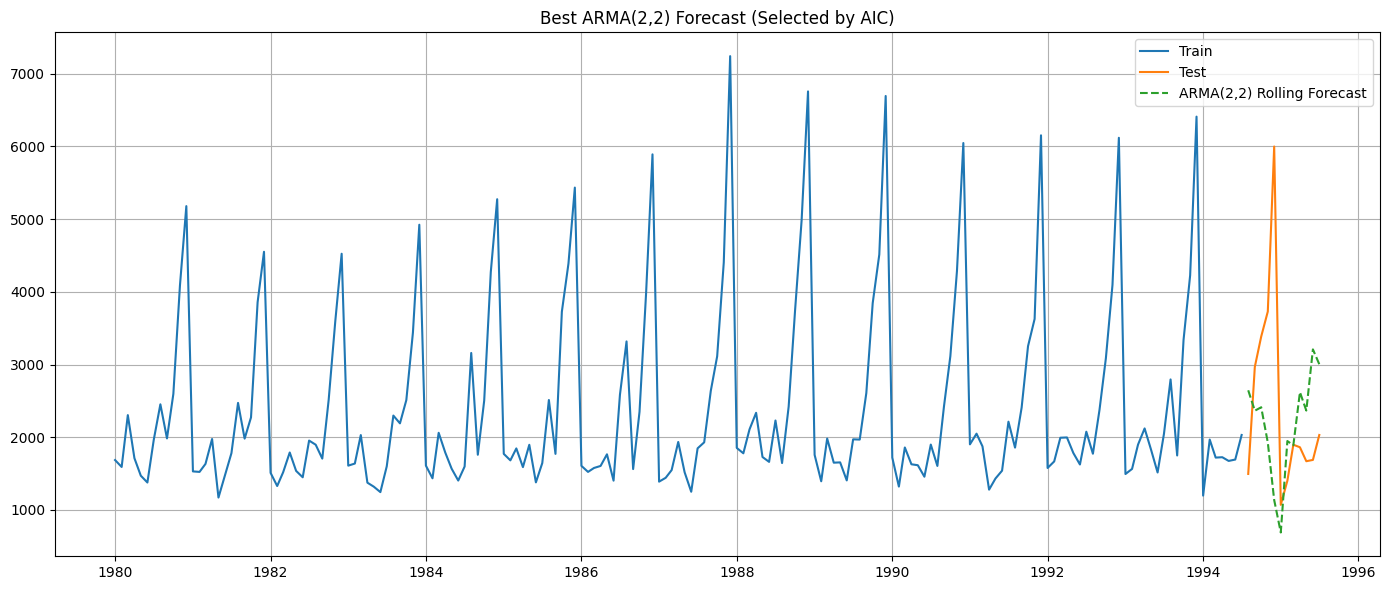

In [24]:
def rolling_forecast(series_diff: pd.Series, train_len: int, horizon: int, window: int, order: tuple):
    """Rolling-window forecast for an ARIMA(p,0,q) model on a (differenced) series."""
    total_len = train_len + horizon
    preds = []
    for i in range(train_len, total_len, window):
        model = ARIMA(series_diff[:i], order=order)
        res = model.fit()
        end = min(i + window, total_len)
        forecast = res.get_prediction(i, end - 1).predicted_mean
        preds.extend(forecast)
    return preds[:horizon]

def undo_diff_and_score(pred_diff, last_train_level, actual_levels):
    """Cumulatively sum differenced predictions back onto the last observed
    training level, then compute RMSE against actual (undifferenced) values."""
    pred_level = last_train_level + np.cumsum(pred_diff)
    rmse = np.sqrt(mean_squared_error(actual_levels, pred_level))
    return pd.Series(pred_level, index=actual_levels.index), rmse

horizon = len(test)
window = 2

sales_diff_series = df['Sparkling_diff']
train_len = len(train)

pred_ARMA_diff = rolling_forecast(sales_diff_series, train_len, horizon, window, order=(best_p, 0, best_q))

arma_forecast, rmse_arma = undo_diff_and_score(
    pred_ARMA_diff,
    train['Sparkling'].iloc[-1],
    test['Sparkling']
)
# add_result(f'ARMA({best_p},{best_q}) [AIC-selected]', rmse_arma) # This function is not defined

plt.figure(figsize=(14,6))
plt.plot(train['Sparkling'], label='Train')
plt.plot(test['Sparkling'], label='Test')
plt.plot(arma_forecast, label=f'ARMA({best_p},{best_q}) Rolling Forecast', linestyle='--')
plt.title(f'Best ARMA({best_p},{best_q}) Forecast (Selected by AIC)')
plt.legend(); plt.grid(True)
plt.tight_layout()
plt.show()

### 20. ARMA Model Rolling Forecast and Evaluation

This section defines functions for rolling forecasts using the ARMA model on the differenced series and for transforming the differenced predictions back to the original scale (`undo_diff_and_score`). The ARMA model, with the best `p` and `q` values found, is then applied to forecast the test data. The forecast is plotted against the actual values, and its RMSE is calculated. Note: The `add_result` function was commented out as it was not defined elsewhere, but the RMSE is computed.

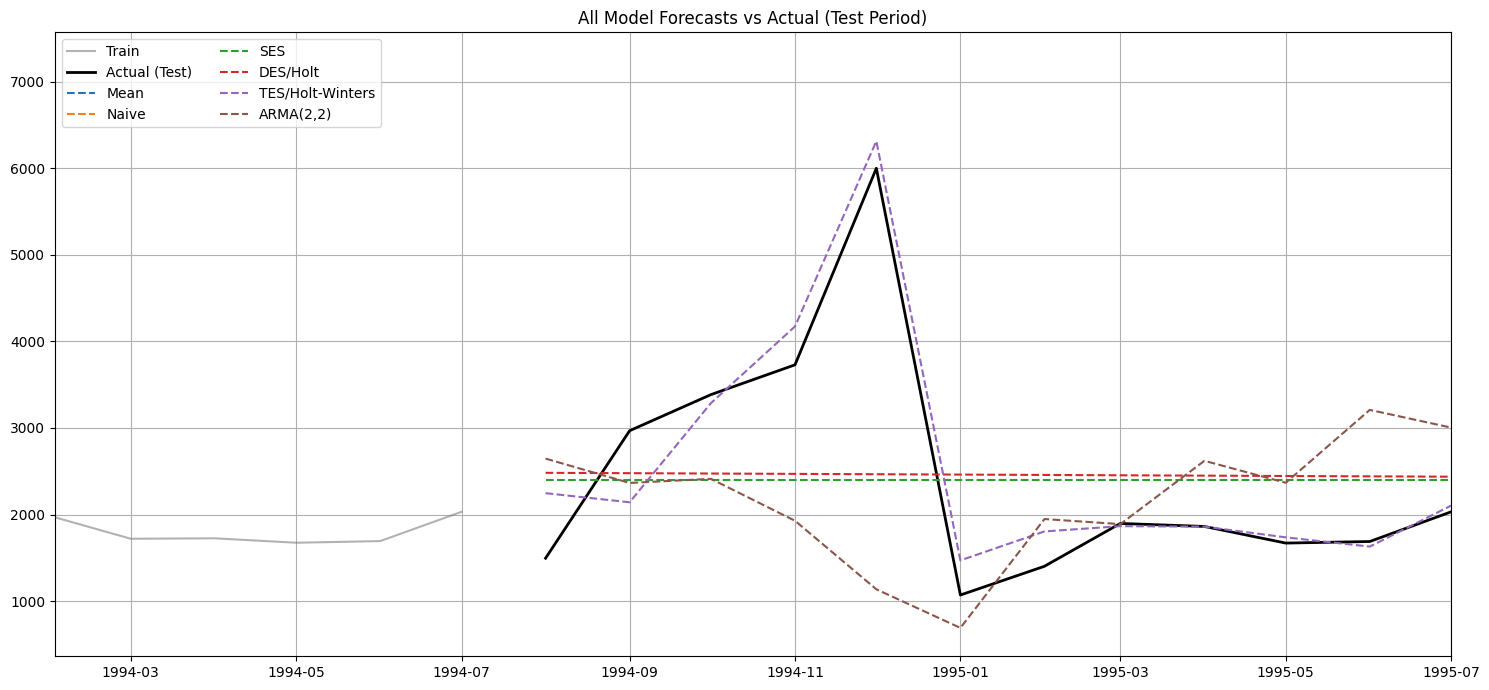

In [25]:
plt.figure(figsize=(15,7))
plt.plot(train['Sparkling'], label='Train', color='grey', alpha=0.6)
plt.plot(test['Sparkling'], label='Actual (Test)', color='black', linewidth=2)
plt.plot(mean_forecast, label='Mean', linestyle='--')
plt.plot(last_value_forecast, label='Naive', linestyle='--')
plt.plot(ses_forecast, label='SES', linestyle='--')
plt.plot(des_forecast, label='DES/Holt', linestyle='--')
plt.plot(tes_forecast, label='TES/Holt-Winters', linestyle='--')
plt.plot(arma_forecast, label=f'ARMA({best_p},{best_q})', linestyle='--')
plt.xlim(test.index.min() - pd.DateOffset(months=6), test.index.max())
plt.title('All Model Forecasts vs Actual (Test Period)')
plt.legend(loc='upper left', ncol=2)
plt.grid(True)
plt.tight_layout()
plt.show()

### 21. Comparison of All Model Forecasts

This final plot compares the forecasts from all the developed models (Mean, Naive/Last Value, SES, DES/Holt, TES/Holt-Winters, and ARMA) against the actual test data. This visual comparison helps in understanding which models performed best in capturing the patterns and trends in the sparkling sales data.